In [1]:
import polars as pl
from tcrtrifold.tcrdock_utils import (
    dgeom_ndarr_from_dgeom_series,
    mn_distr_from_dgeom_ndarr,
    mn_distance_from,
    un_cossin_embed,
)
from tcrtrifold.utils import filter_to_cog_thresh, FORMAT_ANTIGEN_COLS, FORMAT_TCR_COLS

cresta_conf = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.conf_af3.parquet"
)
cresta_tcrdock = pl.read_parquet(
    "../../data/cresta/triad/staged/cresta_triad.af3_tcrdock.parquet"
)
cresta = cresta_conf.join(
    cresta_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

iedb_II_conf = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.conf_af3.parquet"
)
iedb_II_tcrdock = pl.read_parquet(
    "../../data/iedb_II/triad/staged/iedb_II_triad.af3_tcrdock.parquet"
)
iedb_II = iedb_II_conf.join(
    iedb_II_tcrdock.select("pred_dgeom_4", "job_name").with_columns(
        pl.col("pred_dgeom_4").struct.unnest()
    ),
    on="job_name",
    how="inner",
)

assay_type = pl.read_parquet("../../data/iedb_meta/assay_type.parquet")

iedb_II_n = iedb_II.filter(~pl.col("cognate")).explode("receptor_id")

iedb_II_at = (
    iedb_II.filter(pl.col("cognate"))
    .explode("receptor_id")
    .join(assay_type, on="receptor_id")
    .filter(
        pl.col("assay_type").is_in(
            ["x-ray crystallography", "surface plasmon resonance (SPR)"]
        )
    )
)

iedb_II_n = iedb_II_n.join(
    iedb_II_at.select(FORMAT_ANTIGEN_COLS).unique(), on=FORMAT_ANTIGEN_COLS
)

iedb_II = pl.concat([iedb_II_at.select(pl.exclude("assay_type")), iedb_II_n])


template_dgeom = pl.read_csv(
    "../../data/pdb/raw/ternary_templates_v2.tsv", separator="\t"
).with_columns(
    pl.struct(
        **{
            k: pl.col(k)
            for k in [
                "d",
                "torsion",
                "mhc_unit_x_is_negative",
                "tcr_unit_y",
                "tcr_unit_z",
                "tcr_unit_x_is_negative",
                "mhc_unit_y",
                "mhc_unit_z",
            ]
        }
    ).alias("dgeom"),
    pl.when(pl.col("mhc_class") == 1)
    .then(pl.lit("I"))
    .otherwise(pl.lit("II"))
    .alias("mhc_class"),
)

class_II_t_dgeom = dgeom_ndarr_from_dgeom_series(
    template_dgeom.filter(pl.col("mhc_class") == "II").select("dgeom").to_series()
)

class_II_distr = mn_distr_from_dgeom_ndarr(class_II_t_dgeom)

_, iedb_II_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(iedb_II.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

iedb_II = iedb_II.with_columns(pl.Series(name="p_dgeom", values=iedb_II_p_dgeom))

_, cresta_p_dgeom = mn_distance_from(
    dgeom_ndarr_from_dgeom_series(cresta.select("pred_dgeom_4").to_series()),
    *class_II_distr,
)

cresta = cresta.with_columns(pl.Series(name="p_dgeom", values=cresta_p_dgeom))

In [2]:
import xgboost as xgb

iedb_II_np = iedb_II.select(
    [
        # "d",
        # "mhc_unit_y",
        # "mhc_unit_z",
        # "tcr_unit_y",
        # "tcr_unit_z",
        # "torsion",
        # "p_dgeom",
        "mean_p_tcr_pae",
        # "tcr_mhc_contacts",
        # "peptide_tcr_contacts",
        # "peptide_mean_pLDDT",
        "cognate",
    ]
).to_numpy()

iedb_II_X = iedb_II_np[:, :-1]
iedb_II_y = iedb_II_np[:, -1]


cresta_np = cresta.select(
    [
        # "d",
        # "mhc_unit_y",
        # "mhc_unit_z",
        # "tcr_unit_y",
        # "tcr_unit_z",
        # "torsion",
        # "p_dgeom",
        "mean_p_tcr_pae",
        # "tcr_mhc_contacts",
        # "peptide_tcr_contacts",
        # "peptide_mean_pLDDT",
        "cognate",
    ]
).to_numpy()

cresta_X = cresta_np[:, :-1]
cresta_y = cresta_np[:, -1]

clf = xgb.XGBRegressor(tree_method="exact")
xgb_reg = clf.fit(cresta_X, cresta_y)

pred = xgb_reg.predict(iedb_II_X)

iedb_II_pred = iedb_II.with_columns(pl.Series(name="xgb_pred", values=pred))

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

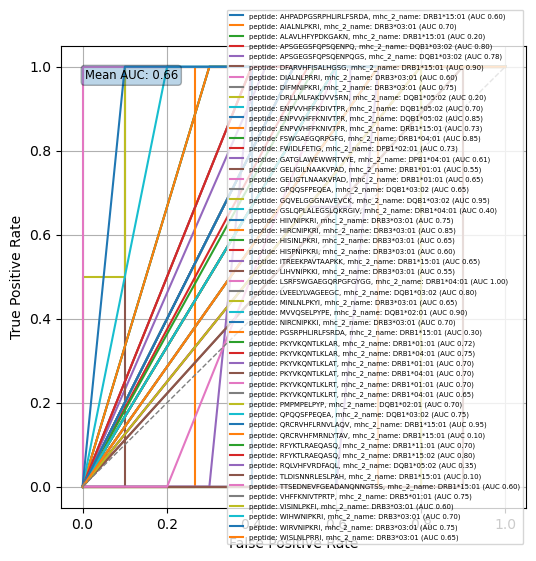

In [3]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    iedb_II_pred,
    "xgb_pred",
)

plot_auc_per_antigen(auc_df, id_cols=["peptide", "mhc_2_name"])

<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

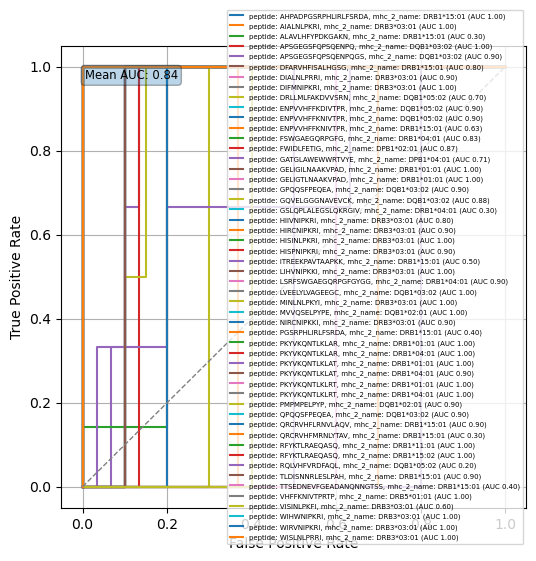

In [4]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    iedb_II.with_columns((1 - pl.col("mean_p_tcr_pae")).alias("mean_p_tcr_pae")),
    "mean_p_tcr_pae",
)

plot_auc_per_antigen(auc_df, id_cols=["peptide", "mhc_2_name"])

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

iedb_II_np = iedb_II.select(
    [
        "d",
        "mhc_unit_y",
        "mhc_unit_z",
        "tcr_unit_y",
        "tcr_unit_z",
        "torsion",
        "p_dgeom",
        "mean_p_tcr_pae",
        "tcr_mhc_contacts",
        "peptide_tcr_contacts",
        "peptide_mean_pLDDT",
        "cognate",
    ]
).to_numpy()

iedb_II_X = iedb_II_np[:, :-1]
iedb_II_y = iedb_II_np[:, -1]


cresta_np = cresta.select(
    [
        "d",
        "mhc_unit_y",
        "mhc_unit_z",
        "tcr_unit_y",
        "tcr_unit_z",
        "torsion",
        "p_dgeom",
        "mean_p_tcr_pae",
        "tcr_mhc_contacts",
        "peptide_tcr_contacts",
        "peptide_mean_pLDDT",
        "cognate",
    ]
).to_numpy()

cresta_X = cresta_np[:, :-1]
cresta_y = cresta_np[:, -1]

clf = MLPClassifier(hidden_layer_sizes=(5,))
xgb_reg = clf.fit(cresta_X, cresta_y)

pred = xgb_reg.predict(iedb_II_X)

iedb_II_pred = iedb_II.with_columns(pl.Series(name="xgb_pred", values=pred))

/home/lwoods/miniconda3/envs/tcrtrifold-experiments/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


<Axes: xlabel='False Positive Rate', ylabel='True Positive Rate'>

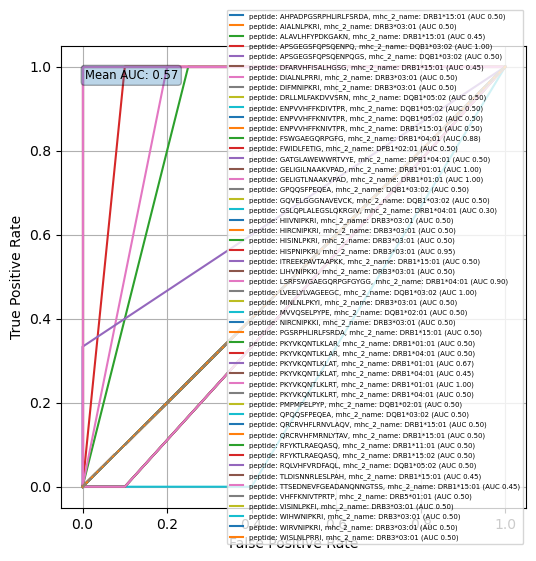

In [27]:
from tcrtrifold.eval_utils import antigen_raw_score_auc
from tcrtrifold.viz_utils import plot_auc_per_antigen

auc_df = antigen_raw_score_auc(
    iedb_II_pred,
    "xgb_pred",
)

plot_auc_per_antigen(auc_df, id_cols=["peptide", "mhc_2_name"])